Hotazel Steam has asked QuantFolio Solutions to compare two regression forecasting models to determine which model predicts monthly revenue more accurately.

Model 1 predicts revenue using production.

Model 2 predicts revenue using Cooling Degree Days (coolDD).

The models will be trained using historical data and evaluated using testing data. Their forecasting accuracy will be compared using Mean Absolute Percentage Error (MAPE).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:,.2f}'.format

Step 1 - Import the Dataset

The first step is to load the Hotazel Steam dataset and inspect its contents to ensure the data has been imported correctly.

In [ ]:
HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')

In [ ]:
HS_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   type        48 non-null     object
 1   date        48 non-null     object
 2   revenue     48 non-null     int64 
 3   production  48 non-null     int64 
 4   coolDD      48 non-null     int64 
 5   heatDD      48 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 2.4+ KB


In [ ]:
display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


Step 2 - Prepare the Data

The date column is converted into a DateTime object so that it can be used for plotting and time-series analysis.

In [ ]:
HS_data['date'] = pd.to_datetime(HS_data['date'])

Step 3 - Explore the Data

The summary statistics provide an overview of the variables used in the regression models.

In [ ]:
display(HS_data.describe())

,revenue,production,coolDD,heatDD
count,48.00,48.00,48.00,48.00
mean,"14,032,843.17","493,033.83",113.27,367.23
std,"5,243,896.41","177,103.43",158.47,359.75
min,"4,809,952.00","151,104.00",0.00,0.00
25%,"10,325,796.00","371,474.00",0.00,10.50
50%,"13,542,764.00","502,280.00",21.00,258.50
75%,"17,865,242.00","646,926.00",203.75,689.25
max,"26,792,280.00","805,600.00",505.00,"1,123.00"


Step 4 - Visualize Revenue

The graph below shows monthly revenue over time.

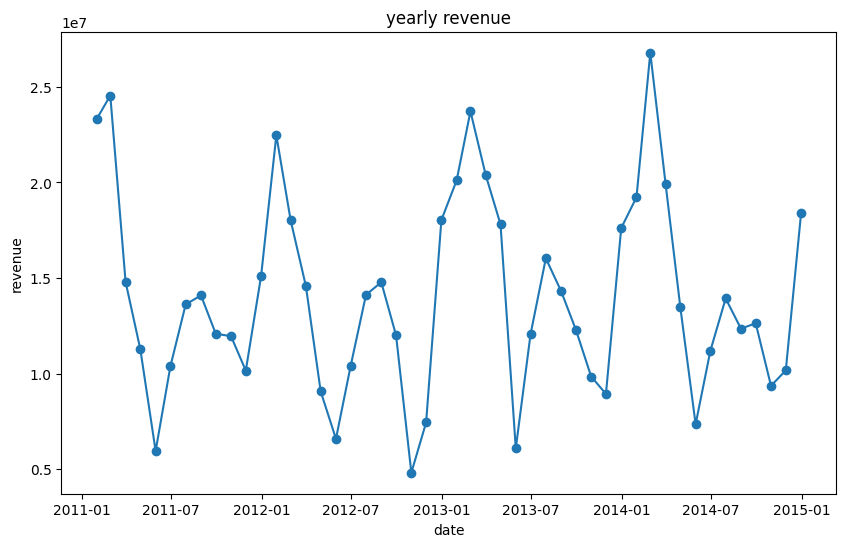

In [ ]:
plt.figure(figsize=(10,6))

plt.title('yearly revenue')

plt.xlabel('date')
plt.ylabel('revenue')

# plt.plot(data that should be on the x axis, data that should be on the y axis, visual stuff)
plt.plot(HS_data['date'], HS_data['revenue'], marker='o')

Step 5 - Correlation Analysis

Correlation helps determine how strongly each variable is related to revenue.

In [ ]:
HS_data.loc[:,['revenue','production','coolDD','heatDD']].corr()

,revenue,production,coolDD,heatDD
revenue,1.00,0.63,-0.17,0.69
production,0.63,1.00,0.51,0.03
coolDD,-0.17,0.51,1.00,-0.72
heatDD,0.69,0.03,-0.72,1.00


Step 6 - Separate Training and Testing Data

The training data will be used to build the regression models.

The testing data will only be used to evaluate forecasting accuracy.

In [ ]:
dt4training = HS_data.loc[HS_data['type']=='dt4training']
dt4testing = HS_data.loc[HS_data['type']=='dt4testing']

display(dt4training)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


Model 1: This model predicts monthly revenue using only production.

In [ ]:
y = dt4training.loc[:, 'revenue']

x = dt4training.loc[:, 'production']

x = sm.add_constant(x)

model1 = sm.OLS(y,x).fit()

model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     22.35
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           3.86e-05
Time:                        00:11:05   Log-Likelihood:                -598.32
No. Observations:                  36   AIC:                             1201.
Df Residuals:                      34   BIC:                             1204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.898e+06   2.01e+06      2.431      0.020    8.03e+05    8.99e+06
production    18.9920      4.017      4.728      0.000      10.828      27.156
==============================================================================
Omnibus:                        5.412   Durbin-Watson:                   0.444
Prob(Omnibus):                  0.067   Jarque-Bera (JB):                2.625
Skew:                           0.392   Prob(JB):                        0.269
Kurtosis:                       1.934   Cond. No.                     1.47e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.47e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The regression equation estimated above will be used to forecast the testing observations.

In [ ]:
x_test = dt4testing.loc[:, 'production']
x_test = sm.add_constant(x_test)

model1.predict(x_test)

,0
36,"16,414,428.69"
37,"18,460,401.82"
38,"20,197,640.55"
39,"12,035,930.72"
40,"10,202,060.55"
41,"14,727,936.65"
42,"19,131,656.04"
43,"17,497,582.00"
44,"18,223,533.25"
45,"12,717,212.73"


In [ ]:
model1_assessment = dt4testing.copy()
model1_assessment['model1_predicted_revenue'] = model1.predict(x_test)
model1_assessment['model1_pctError'] = abs(
    model1_assessment['revenue']-model1_assessment['model1_predicted_revenue'])/model1_assessment['revenue']


display(model1_assessment)

,type,date,revenue,production,coolDD,heatDD,model1_predicted_revenue,model1_pctError
36,dt4testing,2014-01-31,19228840,606400,0,1123,"16,414,428.69",0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,"18,460,401.82",0.31
38,dt4testing,2014-03-31,19935840,805600,0,866,"20,197,640.55",0.01
39,dt4testing,2014-04-30,13468000,375856,0,412,"12,035,930.72",0.11
40,dt4testing,2014-05-31,7344128,279296,49,88,"10,202,060.55",0.39
41,dt4testing,2014-06-30,11196216,517600,230,0,"14,727,936.65",0.32
42,dt4testing,2014-07-31,13929472,749472,380,0,"19,131,656.04",0.37
43,dt4testing,2014-08-31,12352176,663432,322,0,"17,497,582.00",0.42
44,dt4testing,2014-09-30,12628944,701656,178,14,"18,223,533.25",0.44
45,dt4testing,2014-10-31,9361000,411728,24,166,"12,717,212.73",0.36


In [ ]:
model1_assessment['model1_pctError'].mean()

np.float64(0.2542315606071484)

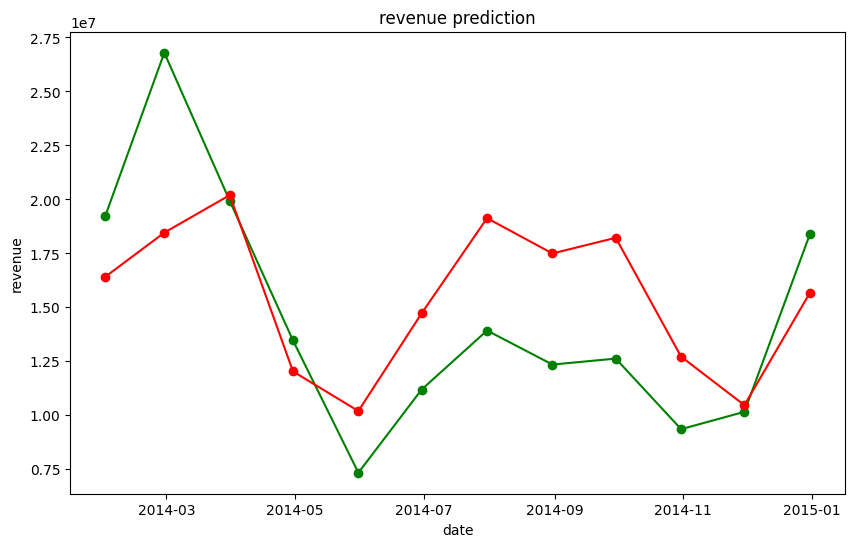

In [ ]:
plt.figure(figsize=(10,6))

plt.title('revenue prediction')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model1_assessment['date'], model1_assessment['revenue'], marker='o', color = 'green')
plt.plot(model1_assessment['date'], model1_assessment['model1_predicted_revenue'], marker='o', color = 'red')

Model 2 - This model predicts monthly revenue using only coolDD.

In [ ]:
y = dt4training["revenue"]

x = dt4training["coolDD"]

x = sm.add_constant(x)

model2 = sm.OLS(y,x).fit()

model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                    0.5883
Date:                Sat, 11 Jul 2026   Prob (F-statistic):              0.448
Time:                        00:20:59   Log-Likelihood:                -607.10
No. Observations:                  36   AIC:                             1218.
Df Residuals:                      34   BIC:                             1221.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.434e+07   1.08e+06     13.275      0.000    1.21e+07    1.65e+07
coolDD     -4113.9355   5363.430     -0.767      0.448    -1.5e+04    6785.866
==============================================================================
Omnibus:                        0.850   Durbin-Watson:                   0.964
Prob(Omnibus):                  0.654   Jarque-Bera (JB):                0.822
Skew:                           0.142   Prob(JB):                        0.663
Kurtosis:                       2.317   Cond. No.                         249.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
x_test = dt4testing.loc[:, 'coolDD']
x_test = sm.add_constant(x_test)

model2.predict(x_test)

,0
36,"14,341,632.04"
37,"14,341,632.04"
38,"14,341,632.04"
39,"14,341,632.04"
40,"14,140,049.20"
41,"13,395,426.88"
42,"12,778,336.56"
43,"13,016,944.82"
44,"13,609,351.53"
45,"14,242,897.59"


In [ ]:
model2_assessment = dt4testing.copy()
model2_assessment['model2_predicted_revenue'] = model2.predict(x_test)
model2_assessment['model2_pctError'] = abs(
    model2_assessment['revenue']-model2_assessment['model2_predicted_revenue'])/model2_assessment['revenue']


display(model2_assessment)

,type,date,revenue,production,coolDD,heatDD,model2_predicted_revenue,model2_pctError
36,dt4testing,2014-01-31,19228840,606400,0,1123,"14,341,632.04",0.25
37,dt4testing,2014-02-28,26792280,714128,0,938,"14,341,632.04",0.46
38,dt4testing,2014-03-31,19935840,805600,0,866,"14,341,632.04",0.28
39,dt4testing,2014-04-30,13468000,375856,0,412,"14,341,632.04",0.06
40,dt4testing,2014-05-31,7344128,279296,49,88,"14,140,049.20",0.93
41,dt4testing,2014-06-30,11196216,517600,230,0,"13,395,426.88",0.20
42,dt4testing,2014-07-31,13929472,749472,380,0,"12,778,336.56",0.08
43,dt4testing,2014-08-31,12352176,663432,322,0,"13,016,944.82",0.05
44,dt4testing,2014-09-30,12628944,701656,178,14,"13,609,351.53",0.08
45,dt4testing,2014-10-31,9361000,411728,24,166,"14,242,897.59",0.52


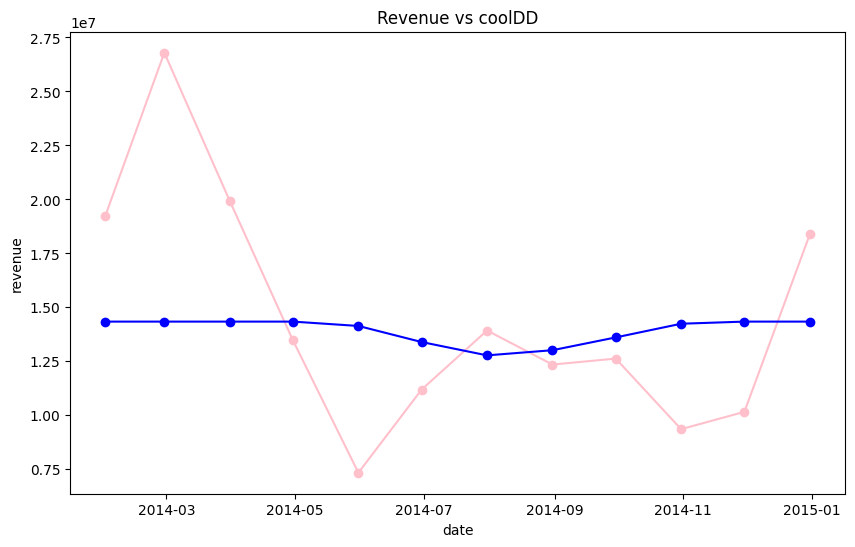

In [ ]:
plt.figure(figsize=(10,6))

plt.title('Revenue vs coolDD')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model2_assessment['date'], model2_assessment['revenue'], marker='o', color = 'pink')
plt.plot(model2_assessment['date'], model2_assessment['model2_predicted_revenue'], marker='o', color = 'blue')

Step 7 - Compare Both Models

The graph below compares the actual revenue with the forecasts produced by both regression models.

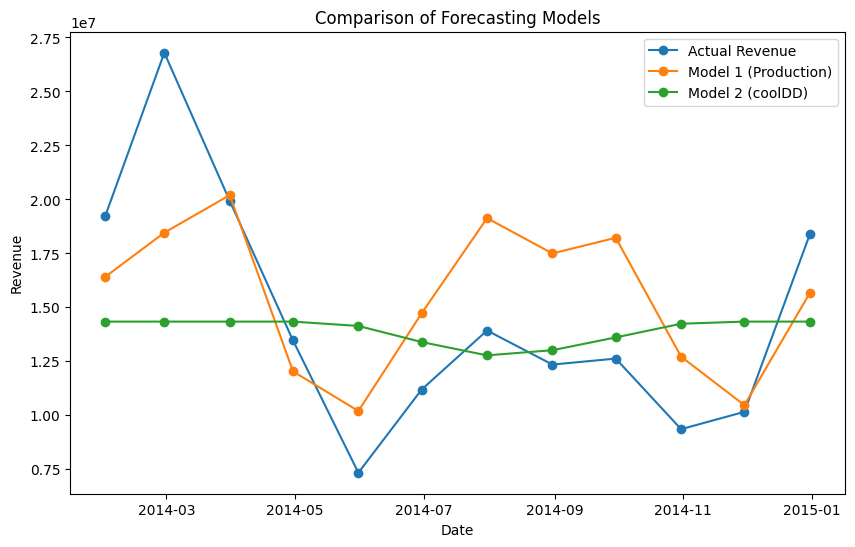

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(dt4testing["date"],
         dt4testing["revenue"],
         marker="o",
         label="Actual Revenue")

plt.plot(dt4testing["date"],
         model1_assessment["model1_predicted_revenue"],
         marker="o",
         label="Model 1")

plt.plot(dt4testing["date"],
         model2_assessment["model2_predicted_revenue"],
         marker="o",
         label="Model 2")

plt.title("Comparison of Forecasting Models")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.legend([
    "Actual Revenue",
    "Model 1 (Production)",
    "Model 2 (coolDD)"
])

## Memo

To: Management, Hotazel Steam

From: QuantFolio Solutions

Subject: Comparison of Revenue Forecasting Models

Two regression models were created to forecast monthly revenue. Model 1 used production as the explanatory variable, and Model 2 used Cooling Degree Days (coolDD). The historical data was divided into separate training and testing datasets for an unbiased evaluation of forecasting performance.

The models were compared using Mean Absolute Percentage Error (MAPE), and a lower MAPE indicates more accurate predictions. Model 1 produced a MAPE of 25.42%, while Model 2 produced a MAPE of 29.60%. The comparison graph shows that the production-based model follows the trend in actual revenue more closely than the coolDD model.

Based on these results, Model 1 is recommended for forecasting future monthly revenue because it achieved the lower forecasting error and demonstrated better predictive performance on the testing data.